## 데이터분석 모형 (6단원-1 통계)

### 1.수업을 위한 data  활용을 위해 깃허브 연동하기

In [ ]:
!git clone 'https://'github.com/KangKyungHwa/DSMH_2/''

Cloning into 'DSMH_2'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 35 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 544.56 KiB | 3.97 MiB/s, done.
Resolving deltas: 100% (4/4), done.


### 2. 원활한 한글 인식을 위해 폰트 설치

In [ ]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

### 3. 나눔고딕 설치

In [ ]:
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.unicode_minus'] = False

### 4.현재 설치된 폰트 확인

In [ ]:
import matplotlib.pyplot as plt

print("현재 Matplotlib 폰트 설정:", plt.rcParams['font.family']) #현재 설치된 폰트 확인


현재 Matplotlib 폰트 설정: ['NanumGothic']


### 5. 통계 라이브러리 불러오기 및  실습(1)

### 6-1 예제) A 기업에서 생산하는 건전지의 평균수명을 조사하기 위해 생산된 10개의 건전지를 조사한 수명 시간에 대한 모집단 평균의 95% 신뢰구간 계산하기

In [ ]:
import numpy as np
import scipy.stats as st      # scipy 라이브러리의 통계서브모듈 불러오기
from scipy.stats import t     # stats 서브모듈에서 st.sem(), t.ppf(), st.t.interval() 함수 사용

a = [260,265,250,270,272,258,262,268,270,252]

print('평균=', np.mean(a),'\n')
print('표준편차=', np.std(a),'\n')         # 표준편차: 데이터셋 자체의 산포도를 측정
print('표준오차=', st.sem(a),'\n')         # 표본 통계량의 정확도를 측정
print('t값=', t.ppf(0.975,10-1),'\n')
print('신뢰구간 t.interval = ','\n')
print(st.t.interval(0.95, len(a)-1, loc=np.mean(a), scale=st.sem(a)),'\n')

평균= 262.7 

표준편차= 7.294518489934754 

표준오차= 2.4315061633115844 

t값= 2.2621571628540993 

신뢰구간 t.interval =  

(np.float64(257.1995509161408), np.float64(268.20044908385916)) 



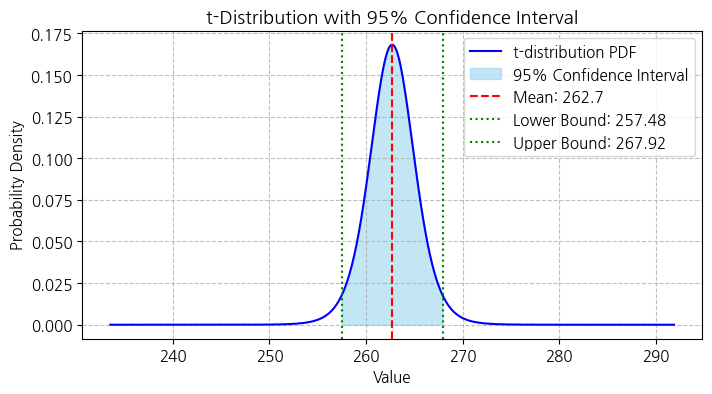

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# 위의 예제 시가화
n = len(a)
mean = np.mean(a)
std = np.std(a)
confidence_level = 0.95

# 평균에 대한 표준 오차
sem = std / np.sqrt(n)

# 신뢰구간 계산
lower_bound, upper_bound = st.t.interval(confidence_level, df=n-1, loc=mean, scale=sem)

# 플롯을 위한 x 값 생성 (분포의 더 넓은 범위를 포함)
x = np.linspace(mean - 4 * sem * np.sqrt(n), mean + 4 * sem * np.sqrt(n), 500)

# Calculate the probability density function (PDF) for the t-distribution
df = n - 1 # degrees of freedom (자유도)
pdf = st.t.pdf(x, df, loc=mean, scale=sem)  # loc : 표본평균

# plot 그래프 만들기
plt.figure(figsize=(8, 4))
plt.plot(x, pdf, color='blue', label='t-distribution PDF')

# Shade the confidence interval area
x_interval = np.linspace(lower_bound, upper_bound, 100)
y_interval = st.t.pdf(x_interval, df, loc=mean, scale=sem)
plt.fill_between(x_interval, y_interval, color='skyblue', alpha=0.5, label='95% Confidence Interval')

# Add vertical lines for the mean and interval bounds
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean}')
plt.axvline(lower_bound, color='green', linestyle=':', label=f'Lower Bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='green', linestyle=':', label=f'Upper Bound: {upper_bound:.2f}')

# Add plot details
plt.title('t-Distribution with 95% Confidence Interval')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

### 6. 통계 실습(2)

### 사당에서 출발하는 통학버스의 학교도착 소요시간을 25번 조사한 결과 평균이 35분, 표준편차는 5분으로 조사되었다.
### 소요시간 평균에 대한 95% 신뢰구간을 계산하기

In [ ]:
import scipy.stats as st
from scipy.stats import t

n2=25
mean2=35
std2=5
sem2 = std2 / np.sqrt(2)

print('신뢰구간 t.interval =', '\n')
print(st.t.interval(0.95, n2-1, loc=mean2, scale=sem2))

신뢰구간 t.interval = 

(np.float64(27.703016656958326), np.float64(42.296983343041674))


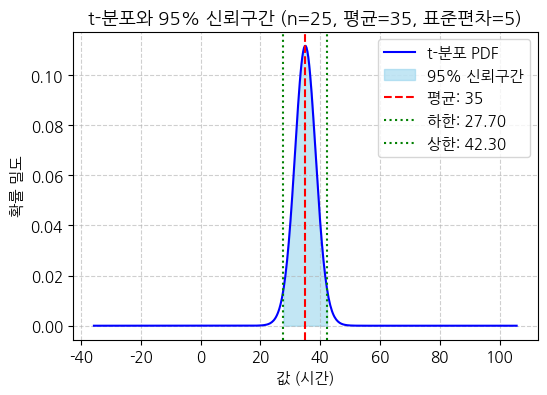

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# 주어진 문제의 매개변수 설정
n2 = 25
mean2 = 35
std2 = 5
confidence_level = 0.95

# 표본 평균의 표준 오차 (standard error of the mean) 계산
# t.interval의 scale 매개변수는 표본 표준편차가 아닌 표본 평균의 표준 오차를 의미
sem2 = std2 / np.sqrt(2)

# 신뢰구간 계산
lower_bound2, upper_bound2 = st.t.interval(confidence_level, df=n2-1, loc=mean2, scale=sem2)

# 플롯을 위한 x 값 생성 (분포의 더 넓은 범위를 포함하도록)
x = np.linspace(mean2 - 4 * sem2 * np.sqrt(n2), mean2 + 4 * sem2 * np.sqrt(n2), 500)

# t-분포의 확률 밀도 함수(PDF) 계산
df2 = n2 - 1 # 자유도
pdf2 = st.t.pdf(x, df2, loc=mean2, scale=sem2)

# 그래프 생성
plt.figure(figsize=(6, 4))
plt.plot(x, pdf2, color='blue', label='t-분포 PDF')

# 신뢰구간 영역 색칠
x_interval = np.linspace(lower_bound2, upper_bound2, 100)
y_interval = st.t.pdf(x_interval, df2, loc=mean2, scale=sem2)
plt.fill_between(x_interval, y_interval, color='skyblue', alpha=0.5, label=f'{confidence_level*100:.0f}% 신뢰구간')

# 평균 및 신뢰구간 경계에 수직선 추가
plt.axvline(mean2, color='red', linestyle='--', label=f'평균: {mean2}')
plt.axvline(lower_bound2, color='green', linestyle=':', label=f'하한: {lower_bound2:.2f}')
plt.axvline(upper_bound2, color='green', linestyle=':', label=f'상한: {upper_bound2:.2f}')

# 그래프 제목 및 라벨 설정
plt.title('t-분포와 95% 신뢰구간 (n=25, 평균=35, 표준편차=5)')
plt.xlabel('값 (시간)')
plt.ylabel('확률 밀도')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 7. 통계 실습(3)

#### 위의 문제에 대해서 같은 신뢰수준(95%)은 그대로 유지한 상태에서 소요시간 조사 수를 10번, 50번, 100번으로 변화시킬 경우 신뢰구간이 어떻게 변할 것인지 예측해 보고 결과를 확인하시오.

In [ ]:
import scipy.stats as st
from scipy.stats import t

n1=10
n2=50
n3=100
mean=35
std=5

print('신뢰구간(95%, n=10) t.interval =', '\n')
print(st.t.interval(0.95, n1-1, loc=mean, scale=std),'\n\n')

print('신뢰구간(95%, n=50) t.interval =''\n')
print(st.t.interval(0.95, n2-1, loc=mean, scale=std),'\n\n')

print('신뢰구간(95%, n=100) t.interval =''\n')
print(st.t.interval(0.95, n3-1, loc=mean, scale=std),'\n\n')

신뢰구간(95%, n=10) t.interval = 

(np.float64(23.689214185729504), np.float64(46.310785814270496)) 


신뢰구간(95%, n=50) t.interval =

(np.float64(24.9521238143538), np.float64(45.0478761856462)) 


신뢰구간(95%, n=100) t.interval =

(np.float64(25.07891524245659), np.float64(44.92108475754341)) 




###더 많은 데이터를 수집할수록 표본 평균이 모집단 평균에 더 가까워질 가능성이 높고, 표본 평균의 변동성이 줄어들어 추정의 정확도가 높아진다는 통계적 의미

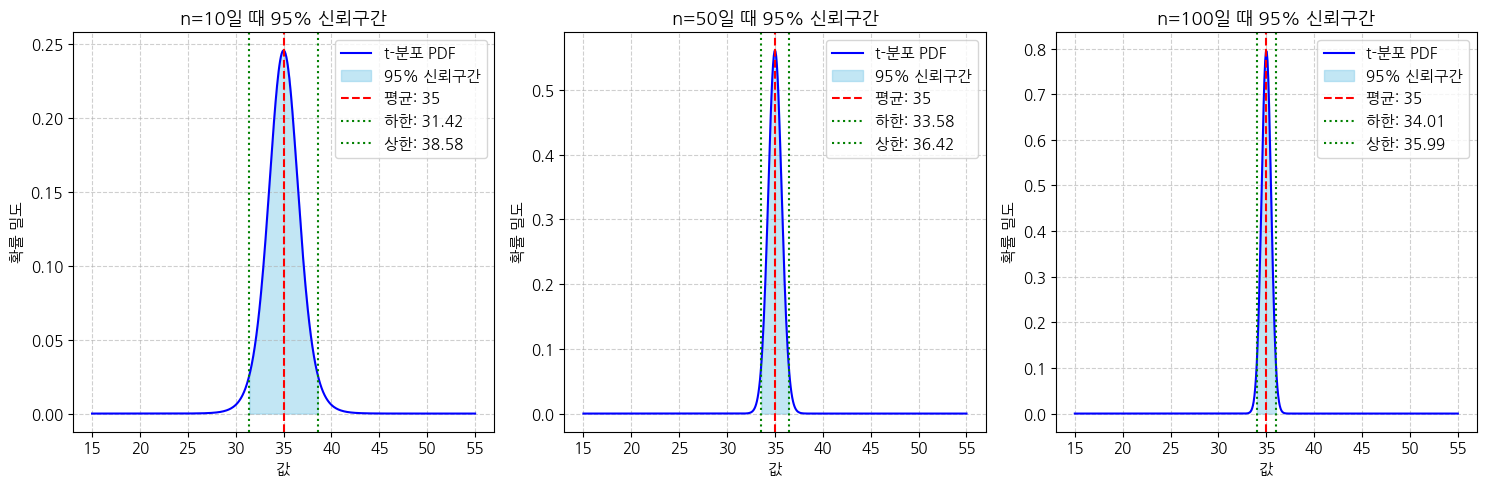

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# 공통 매개변수
mean = 35
std = 5
confidence_level = 0.95

# 다양한 표본 크기
sample_sizes = [10, 50, 100]

plt.figure(figsize=(15, 5))

for i, n_val in enumerate(sample_sizes):
    # 각 표본 크기에 대한 표준 오차 계산
    sem_val = std / np.sqrt(n_val)

    # 각 표본 크기에 대한 신뢰구간 계산
    lower_bound_val, upper_bound_val = st.t.interval(confidence_level, df=n_val-1, loc=mean, scale=sem_val)

    # x 값 범위 설정
    x = np.linspace(mean - 4 * sem_val * np.sqrt(n_val), mean + 4 * sem_val * np.sqrt(n_val), 500)

    # t-분포 PDF 계산
    df_val = n_val - 1 # 자유도
    pdf_val = st.t.pdf(x, df_val, loc=mean, scale=sem_val)

    # 서브플롯 생성
    plt.subplot(1, len(sample_sizes), i + 1)
    plt.plot(x, pdf_val, color='blue', label='t-분포 PDF')

    # 신뢰구간 영역 색칠
    x_interval = np.linspace(lower_bound_val, upper_bound_val, 100)
    y_interval = st.t.pdf(x_interval, df_val, loc=mean, scale=sem_val)
    plt.fill_between(x_interval, y_interval, color='skyblue', alpha=0.5, label=f'{confidence_level*100:.0f}% 신뢰구간')

    # 평균 및 신뢰구간 경계에 수직선 추가
    plt.axvline(mean, color='red', linestyle='--', label=f'평균: {mean}')
    plt.axvline(lower_bound_val, color='green', linestyle=':', label=f'하한: {lower_bound_val:.2f}')
    plt.axvline(upper_bound_val, color='green', linestyle=':', label=f'상한: {upper_bound_val:.2f}')

    plt.title(f'n={n_val}일 때 95% 신뢰구간')
    plt.xlabel('값')
    plt.ylabel('확률 밀도')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # 그래프 간의 간격 조정
plt.show()